In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import rasterio
from rasterio.mask import mask

# ===================== CONFIG (edit if needed) =====================
SHAPE_PATH = r"G:\Hangkai\Anttarctic Vegetation Dynamic\Rock_Map\add_rockoutcrop_landsat_v7.3.shp"
NDVI_DIR   = r"G:\Hangkai\Anttarctic Vegetation Dynamic\Version_2_data\Antractic_Max_NDVI_every_year\WHOLE MAP\LAND"
YEAR_START, YEAR_END = 2002, 2023
NDVI_THRESHOLD = 0.2
PIXEL_AREA_KM2 = 0.25         # each pixel area
OUTPUT_CSV = Path(NDVI_DIR) / "rock_ndvi_over_0p2_by_year.csv"
# ================================================================

def main():
    ndvi_dir = Path(NDVI_DIR)
    if not ndvi_dir.exists():
        raise FileNotFoundError(f"NDVI directory not found: {ndvi_dir}")

    # 1) Load rock polygons
    gdf = gpd.read_file(SHAPE_PATH)
    if gdf.empty:
        raise RuntimeError("Rock shapefile contains no features.")

    # Collect candidate rasters
    tif_paths = sorted(ndvi_dir.glob("*.tif"))
    # Keep only files like YYYY_land.tif within the desired range
    year_file_pairs = []
    pat = re.compile(r"^(\d{4})_land\.tif$", re.IGNORECASE)
    for p in tif_paths:
        m = pat.match(p.name)
        if m:
            y = int(m.group(1))
            if YEAR_START <= y <= YEAR_END:
                year_file_pairs.append((y, p))

    if not year_file_pairs:
        raise RuntimeError(f"No yearly *_land.tif files in {ndvi_dir} for {YEAR_START}-{YEAR_END}.")

    results = []
    for year, tif in year_file_pairs:
        with rasterio.open(tif) as src:
            # Reproject rock polygons to raster CRS if needed
            if gdf.crs is None:
                raise RuntimeError("Rock shapefile has no CRS defined.")
            if gdf.crs != src.crs:
                rocks = gdf.to_crs(src.crs)
            else:
                rocks = gdf

            # Optional: quick skip if no intersection with raster extent
            raster_bounds_geom = gpd.GeoSeries([box(*src.bounds)], crs=src.crs)
            if rocks.intersects(raster_bounds_geom.iloc[0]).sum() == 0:
                results.append({"year": year, "count_pixels": 0, "area_km2": 0.0})
                continue

            # 2) Mask raster to rock polygons (keep full raster shape, crop=False)
            #    This returns a masked array where pixels OUTSIDE rocks are masked=True
            out, out_transform = mask(src, rocks.geometry, crop=False, filled=False)
            ndvi = out[0]  # 1-band

            # Determine nodata
            nodata = src.nodata
            # valid pixels: not masked, finite, and (if nodata is set) not equal to nodata
            valid_mask = (~ndvi.mask) & np.isfinite(ndvi.data)
            if nodata is not None:
                valid_mask = valid_mask & (ndvi.data != nodata)

            # 3) NDVI > 0.2 within rock polygons
            sel = valid_mask & (ndvi.data > NDVI_THRESHOLD)
            count = int(np.count_nonzero(sel))
            area = count * PIXEL_AREA_KM2

            results.append({"year": year, "count_pixels": count, "area_km2": area})
            print(f"{year}: {count} px > {NDVI_THRESHOLD} within rock (area {area:.2f} km²)")

    # 4) Save CSV
    df = pd.DataFrame(results).sort_values("year")
    df.to_csv(OUTPUT_CSV, index=False)
    print(f"\nSaved: {OUTPUT_CSV}")
    print(df)

if __name__ == "__main__":
    main()

2002: 2452 px > 0.2 within rock (area 613.00 km²)
2003: 2799 px > 0.2 within rock (area 699.75 km²)
2004: 3127 px > 0.2 within rock (area 781.75 km²)
2005: 3211 px > 0.2 within rock (area 802.75 km²)
2006: 3090 px > 0.2 within rock (area 772.50 km²)
2007: 3035 px > 0.2 within rock (area 758.75 km²)
2008: 3590 px > 0.2 within rock (area 897.50 km²)
2009: 3257 px > 0.2 within rock (area 814.25 km²)
2010: 3640 px > 0.2 within rock (area 910.00 km²)
2011: 3543 px > 0.2 within rock (area 885.75 km²)
2012: 3346 px > 0.2 within rock (area 836.50 km²)
2013: 3580 px > 0.2 within rock (area 895.00 km²)
2014: 3356 px > 0.2 within rock (area 839.00 km²)
2015: 3196 px > 0.2 within rock (area 799.00 km²)
2016: 4210 px > 0.2 within rock (area 1052.50 km²)
2017: 2877 px > 0.2 within rock (area 719.25 km²)
2018: 3173 px > 0.2 within rock (area 793.25 km²)
2019: 3130 px > 0.2 within rock (area 782.50 km²)
2020: 3115 px > 0.2 within rock (area 778.75 km²)
2021: 3346 px > 0.2 within rock (area 836.50 km²)

In [11]:
# -*- coding: utf-8 -*-
"""
Count NDVI>0.2 pixels overlapping Rock map, per year (2002–2023), with extra masks:
  - Exclude DEM > 500 m   (keep DEM <= 500)
  - Exclude latitude south of 83°S (keep lat > -83)

Inputs:
- Rock shapefile:   G:\Hangkai\Anttarctic Vegetation Dynamic\Rock_Map\add_rockoutcrop_landsat_v7.3.shp
- NDVI rasters dir: G:\Hangkai\Anttarctic Vegetation Dynamic\Version_2_data\Antractic_Max_NDVI_every_year\WHOLE MAP\LAND
  Files named like 2002_land.tif ... 2023_land.tif
- DEM (meters):     G:\Hangkai\Anttarctic Vegetation Dynamic\DEM\Antarctica_DEM.tif

Output: rock_ndvi_over_0p2_by_year.csv in the NDVI folder.
"""

import re
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import rasterio
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling
from rasterio.transform import xy
from pyproj import CRS, Transformer

# ===================== CONFIG (edit if needed) =====================
SHAPE_PATH = r"G:\Hangkai\Anttarctic Vegetation Dynamic\Rock_Map\add_rockoutcrop_landsat_v7.3.shp"
NDVI_DIR   = r"G:\Hangkai\Anttarctic Vegetation Dynamic\Version_2_data\Antractic_Max_NDVI_every_year\WHOLE MAP\LAND"
DEM_PATH   = r"G:\Hangkai\Anttarctic Vegetation Dynamic\DEM\DEM.tif"

YEAR_START, YEAR_END = 2002, 2023
NDVI_THRESHOLD = 0.2
PIXEL_AREA_KM2 = 0.25         # each pixel area (e.g., 500 m × 500 m)
DEM_MAX_M = 500               # keep DEM <= 500 m
LAT_MIN_DEG = -83.0           # keep latitude > -83 (exclude south of 83°S)

# If your DEM lacks an embedded CRS, set it here (e.g., "EPSG:3031" for Antarctic Polar Stereographic).
# If your DEM DOES have a valid CRS, leave this as None.
DEM_CRS_OVERRIDE = None  # e.g., "EPSG:3031"
# ================================================================

def _get_dem_crs(dem_src):
    """Return a pyproj CRS for DEM, honoring override and raising if missing."""
    if DEM_CRS_OVERRIDE is not None:
        return CRS.from_user_input(DEM_CRS_OVERRIDE)
    if dem_src.crs is None:
        raise rasterio.errors.CRSError(
            "DEM has no CRS. Set DEM_CRS_OVERRIDE (e.g., 'EPSG:3031') to the correct CRS."
        )
    return dem_src.crs

def build_static_masks(example_raster_path: Path, dem_path: Path):
    """
    Compute DEM<=500 mask and latitude>-83 mask in the grid of the example raster.
    Returns (dem_keep_mask, lat_keep_mask) as boolean arrays with shape (H, W).
    """
    # Open example NDVI raster to get grid & CRS
    with rasterio.open(example_raster_path) as ref:
        dst_crs = ref.crs
        dst_transform = ref.transform
        height, width = ref.height, ref.width

        # --------- DEM -> reproject to NDVI grid ----------
        with rasterio.open(dem_path) as dem_src:
            dem_crs = _get_dem_crs(dem_src)
            dem_data = dem_src.read(1)  # meters
            dem_on_grid = np.empty((height, width), dtype=np.float32)
            dem_on_grid[:] = np.nan

            reproject(
                source=dem_data,
                destination=dem_on_grid,
                src_transform=dem_src.transform,
                src_crs=dem_crs,
                dst_transform=dst_transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear,
                dst_nodata=np.nan,
            )

        # Build DEM keep mask: valid & <= DEM_MAX_M
        dem_keep = np.isfinite(dem_on_grid) & (dem_on_grid <= DEM_MAX_M)

        # --------- Latitude mask (lat > -83) ----------
        transformer = Transformer.from_crs(dst_crs, "EPSG:4326", always_xy=True)

        # Compute per-row lats (memory-friendly)
        lats = np.empty((height, width), dtype=np.float32)
        xs = np.arange(width, dtype=np.float64)
        ones = np.ones_like(xs)
        for row in range(height):
            x_coords, y_coords = xy(dst_transform, row * ones, xs, offset="center")
            _, lat = transformer.transform(x_coords, y_coords)
            lats[row, :] = lat

        lat_keep = lats > LAT_MIN_DEG

    return dem_keep, lat_keep


def main():
    ndvi_dir = Path(NDVI_DIR)
    if not ndvi_dir.exists():
        raise FileNotFoundError(f"NDVI directory not found: {ndvi_dir}")
    if not Path(DEM_PATH).exists():
        raise FileNotFoundError(f"DEM not found: {DEM_PATH}")

    # 1) Load rock polygons
    gdf = gpd.read_file(SHAPE_PATH)
    if gdf.empty:
        raise RuntimeError("Rock shapefile contains no features.")

    # Collect candidate rasters
    tif_paths = sorted(ndvi_dir.glob("*.tif"))
    # Keep only files like YYYY_land.tif within the desired range
    year_file_pairs = []
    pat = re.compile(r"^(\d{4})_land\.tif$", re.IGNORECASE)
    for p in tif_paths:
        m = pat.match(p.name)
        if m:
            y = int(m.group(1))
            if YEAR_START <= y <= YEAR_END:
                year_file_pairs.append((y, p))

    if not year_file_pairs:
        raise RuntimeError(f"No yearly *_land.tif files in {ndvi_dir} for {YEAR_START}-{YEAR_END}.")

    # ---------- Build static masks (DEM & latitude) once using first raster ----------
    first_year, first_tif = year_file_pairs[0]
    dem_keep_mask, lat_keep_mask = build_static_masks(first_tif, DEM_PATH)
    static_shape = dem_keep_mask.shape

    results = []
    for year, tif in year_file_pairs:
        with rasterio.open(tif) as src:
            # Sanity: ensure same grid as the static masks
            if (src.height, src.width) != static_shape:
                raise RuntimeError(
                    f"Raster grid mismatch for {tif.name}. "
                    f"Expected shape {static_shape}, got {(src.height, src.width)}."
                )

            # Reproject rock polygons to raster CRS if needed
            if gdf.crs is None:
                raise RuntimeError("Rock shapefile has no CRS defined.")
            if gdf.crs != src.crs:
                rocks = gdf.to_crs(src.crs)
            else:
                rocks = gdf

            # Optional: quick skip if no intersection with raster extent
            raster_bounds_geom = gpd.GeoSeries([box(*src.bounds)], crs=src.crs)
            if rocks.intersects(raster_bounds_geom.iloc[0]).sum() == 0:
                results.append({"year": year, "count_pixels": 0, "area_km2": 0.0})
                print(f"{year}: no rock within raster bounds; count 0.")
                continue

            # 2) Mask NDVI by rock polygons (full image size)
            out, _ = mask(src, rocks.geometry, crop=False, filled=False)
            ndvi_ma = out[0]
            ndvi = ndvi_ma.data

            # Determine valid NDVI pixels (inside rocks & finite & not nodata)
            nodata = src.nodata
            inside_rocks = ~ndvi_ma.mask
            valid_mask = inside_rocks & np.isfinite(ndvi)
            if nodata is not None:
                valid_mask &= (ndvi != nodata)

            # 3) Apply DEM & latitude masks
            keep_mask = valid_mask & dem_keep_mask & lat_keep_mask

            # 4) Threshold NDVI > NDVI_THRESHOLD
            sel = keep_mask & (ndvi > NDVI_THRESHOLD)
            count = int(np.count_nonzero(sel))
            area = count * PIXEL_AREA_KM2

            results.append({"year": year, "count_pixels": count, "area_km2": area})
            print(f"{year}: {count} px > {NDVI_THRESHOLD} within rock & DEM<= {DEM_MAX_M} & lat>-83 (area {area:.2f} km²)")

    # 5) Save CSV
    df = pd.DataFrame(results).sort_values("year")
    out_csv = Path(NDVI_DIR) / "rock_ndvi_over_0p2_by_year.csv"
    df.to_csv(out_csv, index=False)
    print(f"\nSaved: {out_csv}")
    print(df)


if __name__ == "__main__":
    main()

2002: 549 px > 0.2 within rock & DEM<= 500 & lat>-83 (area 137.25 km²)
2003: 540 px > 0.2 within rock & DEM<= 500 & lat>-83 (area 135.00 km²)
2004: 769 px > 0.2 within rock & DEM<= 500 & lat>-83 (area 192.25 km²)
2005: 735 px > 0.2 within rock & DEM<= 500 & lat>-83 (area 183.75 km²)
2006: 725 px > 0.2 within rock & DEM<= 500 & lat>-83 (area 181.25 km²)
2007: 693 px > 0.2 within rock & DEM<= 500 & lat>-83 (area 173.25 km²)
2008: 902 px > 0.2 within rock & DEM<= 500 & lat>-83 (area 225.50 km²)
2009: 713 px > 0.2 within rock & DEM<= 500 & lat>-83 (area 178.25 km²)
2010: 788 px > 0.2 within rock & DEM<= 500 & lat>-83 (area 197.00 km²)
2011: 824 px > 0.2 within rock & DEM<= 500 & lat>-83 (area 206.00 km²)
2012: 790 px > 0.2 within rock & DEM<= 500 & lat>-83 (area 197.50 km²)
2013: 791 px > 0.2 within rock & DEM<= 500 & lat>-83 (area 197.75 km²)
2014: 773 px > 0.2 within rock & DEM<= 500 & lat>-83 (area 193.25 km²)
2015: 762 px > 0.2 within rock & DEM<= 500 & lat>-83 (area 190.50 km²)
2016: 

Trend statistics for Rock-overlapped NDVI>0.2 area                        metric         value
0        OLS slope (km²/year)      5.760164
1      OLS slope (km²/decade)     57.601637
2         OLS intercept (km²) -10771.363636
3                          R²      0.172594
4              t-stat (slope)      2.042530
5         p-value (OLS slope)      0.041099
6  Theil–Sen slope (km²/year)      5.441176
7              Mann–Kendall Z      1.777176
8        Mann–Kendall p-value      0.075539
9               Kendall's tau      0.277056


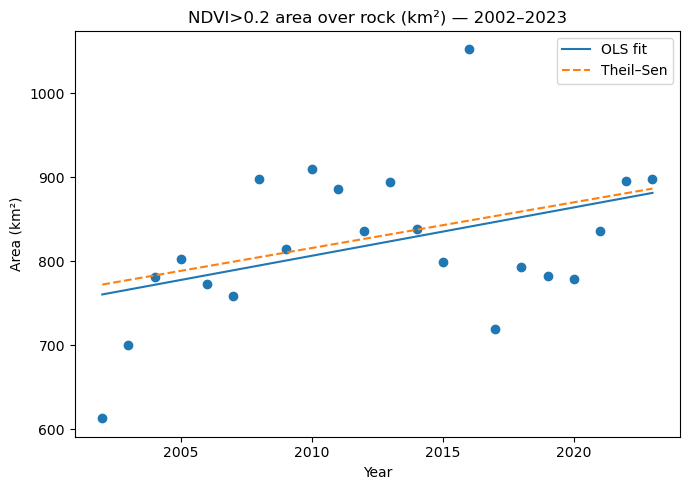

(                       metric         value
 0        OLS slope (km²/year)      5.760164
 1      OLS slope (km²/decade)     57.601637
 2         OLS intercept (km²) -10771.363636
 3                          R²      0.172594
 4              t-stat (slope)      2.042530
 5         p-value (OLS slope)      0.041099
 6  Theil–Sen slope (km²/year)      5.441176
 7              Mann–Kendall Z      1.777176
 8        Mann–Kendall p-value      0.075539
 9               Kendall's tau      0.277056,
 (5.7601637492940885,
  -10771.363636363447,
  0.17259393859015337,
  2.042529879931453,
  0.041098998617312255,
  5.4411764705882355,
  1.777176253967451,
  0.07553924511823107,
  0.27705627705627706))

In [4]:
# Create a DataFrame from the user's table, compute trend stats, and plot.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
import itertools

# ---- Data ----
data = {
    "year": list(range(2002, 2024)),
    "count_pixels": [
        2452,2799,3127,3211,3090,3035,3590,3257,3640,3543,3346,3580,3356,3196,4210,2877,3173,3130,3115,3346,3581,3591
    ],
    "area_km2": [
        613.00,699.75,781.75,802.75,772.50,758.75,897.50,814.25,910.00,885.75,836.50,895.00,839.00,799.00,1052.50,719.25,793.25,782.50,778.75,836.50,895.25,897.75
    ],
}
df = pd.DataFrame(data)

# ---- Linear regression (OLS) ----
x = df["year"].values
y = df["area_km2"].values

# OLS slope/intercept
slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept
# R^2
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot

# Standard error and p-value for slope using classic formulas
n = len(x)
x_mean = np.mean(x)
sxx = np.sum((x - x_mean)**2)
# residual standard error
sigma2 = ss_res / (n - 2)
se_slope = sqrt(sigma2 / sxx)

# t-statistic and two-sided p-value (approx using Student's t CDF via scipy isn't guaranteed available)
# We'll compute p-value using a normal approximation as n is reasonably large (n=22).
t_stat = slope / se_slope
# normal approx p-value
from math import erf
def norm_cdf(z):
    return 0.5 * (1 + erf(z / sqrt(2)))
p_value_ols = 2 * (1 - norm_cdf(abs(t_stat)))

# ---- Theil–Sen robust slope ----
pairs = list(itertools.combinations(range(n), 2))
slopes = [(y[j]-y[i])/(x[j]-x[i]) for i,j in pairs if x[j] != x[i]]
theil_sen_slope = np.median(slopes)
# Intercept via median of y - slope*x
theil_sen_intercept = np.median(y - theil_sen_slope * x)

# ---- Mann–Kendall test (non-parametric) ----
def mann_kendall_test(series):
    s = 0
    ties = {}
    n = len(series)
    for i in range(n-1):
        for j in range(i+1, n):
            diff = series[j] - series[i]
            if diff > 0:
                s += 1
            elif diff < 0:
                s -= 1
            else:
                ties[series[i]] = ties.get(series[i], 0) + 1
    # variance of S with tie correction
    # tie correction: for groups of equal values of size t, add t*(t-1)*(2t+5)
    unique, counts = np.unique(series, return_counts=True)
    tie_term = np.sum(counts*(counts-1)*(2*counts+5))
    var_s = (n*(n-1)*(2*n+5) - tie_term) / 18.0
    # continuity correction
    if s > 0:
        z = (s - 1)/sqrt(var_s)
    elif s < 0:
        z = (s + 1)/sqrt(var_s)
    else:
        z = 0.0
    p = 2 * (1 - norm_cdf(abs(z)))
    # Kendall's tau
    tau = s / (0.5*n*(n-1))
    return s, z, p, tau

S, Z, p_mk, tau = mann_kendall_test(y)

# ---- Package stats ----
stats = pd.DataFrame({
    "metric": [
        "OLS slope (km²/year)",
        "OLS slope (km²/decade)",
        "OLS intercept (km²)",
        "R²",
        "t-stat (slope)",
        "p-value (OLS slope)",
        "Theil–Sen slope (km²/year)",
        "Mann–Kendall Z",
        "Mann–Kendall p-value",
        "Kendall's tau"
    ],
    "value": [
        slope,
        slope*10.0,
        intercept,
        r2,
        t_stat,
        p_value_ols,
        theil_sen_slope,
        Z,
        p_mk,
        tau
    ]
})

print("Trend statistics for Rock-overlapped NDVI>0.2 area", stats)

# ---- Plot ----
plt.figure(figsize=(7,5))
plt.scatter(x, y)
# OLS line
x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, label="OLS fit")
# Theil–Sen line
y_ts = theil_sen_slope * x_line + theil_sen_intercept
plt.plot(x_line, y_ts, linestyle="--", label="Theil–Sen")
plt.title("NDVI>0.2 area over rock (km²) — 2002–2023")
plt.xlabel("Year")
plt.ylabel("Area (km²)")
plt.legend()
plt.tight_layout()
plt.show()

stats, (slope, intercept, r2, t_stat, p_value_ols, theil_sen_slope, Z, p_mk, tau)

Trend (exclude 2002 & 2016) — statistics                         metric        value
0         OLS slope (km²/year)     2.780701
1       OLS slope (km²/decade)    27.807015
2          OLS intercept (km²) -4777.347446
3                           R²     0.080182
4               t-stat (slope)     1.252634
5          p-value (OLS slope)     0.210339
6   Theil–Sen slope (km²/year)     2.687500
7               Mann–Kendall Z     1.168609
8         Mann–Kendall p-value     0.242561
9                Kendall's tau     0.194737
10                   N (years)    20.000000


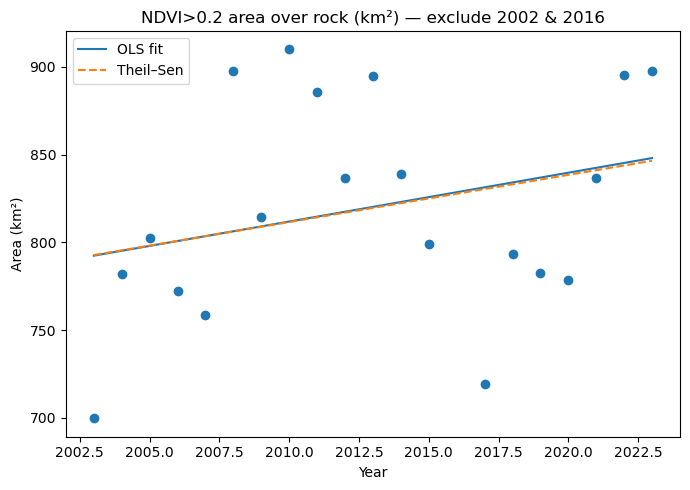

,metric,value
0,OLS slope (km²/year),2.780701
1,OLS slope (km²/decade),27.807015
2,OLS intercept (km²),-4777.347446
3,R²,0.080182
4,t-stat (slope),1.252634
5,p-value (OLS slope),0.210339
6,Theil–Sen slope (km²/year),2.687500
7,Mann–Kendall Z,1.168609
8,Mann–Kendall p-value,0.242561
9,Kendall's tau,0.194737


In [5]:
# Retry with a numeric-friendly MK implementation (avoid boolean subtraction on numpy scalars)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
import itertools

# Data
years = list(range(2003, 2024))  # we will build from original but skip 2002 and 2016
all_years = list(range(2002, 2024))
all_areas = [
    613.00,699.75,781.75,802.75,772.50,758.75,897.50,814.25,910.00,885.75,
    836.50,895.00,839.00,799.00,1052.50,719.25,793.25,782.50,778.75,836.50,
    895.25,897.75
]
df_full = pd.DataFrame({"year": all_years, "area_km2": all_areas})
df2 = df_full[~df_full["year"].isin([2002, 2016])].reset_index(drop=True)

x = df2["year"].values.astype(float)
y = df2["area_km2"].values.astype(float)
n = len(x)

# OLS
slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot
sigma2 = ss_res / (n - 2)
sxx = np.sum((x - np.mean(x))**2)
se_slope = (sigma2 / sxx) ** 0.5
t_stat = slope / se_slope

from math import erf
def norm_cdf(z):
    return 0.5 * (1 + erf(z / (2**0.5)))
p_value_ols = 2 * (1 - norm_cdf(abs(t_stat)))

# Theil–Sen
pairs = list(itertools.combinations(range(n), 2))
ts_slope = np.median([(y[j]-y[i])/(x[j]-x[i]) for i,j in pairs])
ts_intercept = np.median(y - ts_slope * x)

# Mann–Kendall
def mann_kendall_test_numeric(series):
    s = 0
    n = len(series)
    for i in range(n-1):
        for j in range(i+1, n):
            diff = series[j] - series[i]
            if diff > 0:
                s += 1
            elif diff < 0:
                s -= 1
            # ties add 0
    unique, counts = np.unique(series, return_counts=True)
    tie_term = np.sum(counts*(counts-1)*(2*counts+5))
    var_s = (n*(n-1)*(2*n+5) - tie_term) / 18.0
    if s > 0:
        z = (s - 1)/np.sqrt(var_s)
    elif s < 0:
        z = (s + 1)/np.sqrt(var_s)
    else:
        z = 0.0
    p = 2 * (1 - norm_cdf(abs(z)))
    tau = s / (0.5*n*(n-1))
    return s, z, p, tau

S, Z, p_mk, tau = mann_kendall_test_numeric(y)

# Stats table
stats2 = pd.DataFrame({
    "metric": [
        "OLS slope (km²/year)",
        "OLS slope (km²/decade)",
        "OLS intercept (km²)",
        "R²",
        "t-stat (slope)",
        "p-value (OLS slope)",
        "Theil–Sen slope (km²/year)",
        "Mann–Kendall Z",
        "Mann–Kendall p-value",
        "Kendall's tau",
        "N (years)"
    ],
    "value": [
        slope,
        slope*10.0,
        intercept,
        r2,
        t_stat,
        p_value_ols,
        ts_slope,
        Z,
        p_mk,
        tau,
        n
    ]
})

print("Trend (exclude 2002 & 2016) — statistics", stats2)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
plt.plot(x_line, slope * x_line + intercept, label="OLS fit")
plt.plot(x_line, ts_slope * x_line + ts_intercept, linestyle="--", label="Theil–Sen")
plt.title("NDVI>0.2 area over rock (km²) — exclude 2002 & 2016")
plt.xlabel("Year")
plt.ylabel("Area (km²)")
plt.legend()
plt.tight_layout()
plt.show()

stats2


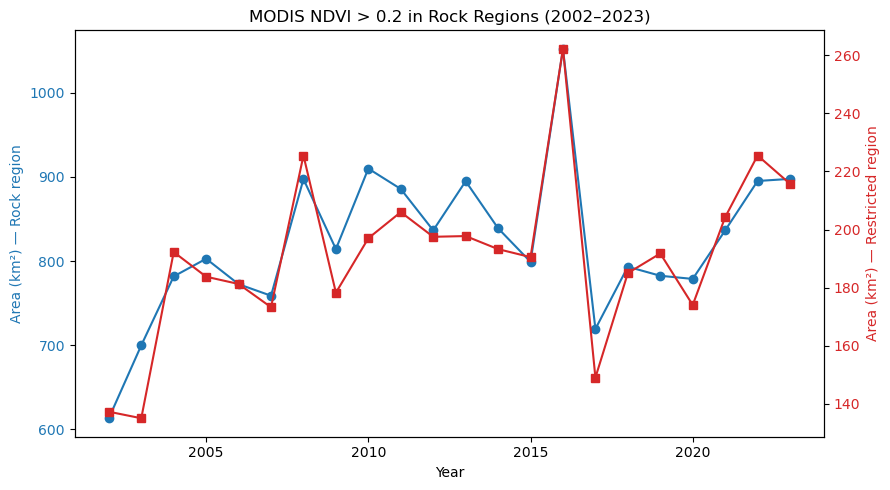

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV
df = pd.read_csv(r"G:\Hangkai\Anttarctic Vegetation Dynamic\Greenness_Area_With_Restrictions.csv")

# Create figure
fig, ax1 = plt.subplots(figsize=(9, 5))

# ---- Left y-axis: Rock region ----
color1 = "tab:blue"
ax1.plot(df["year"], df["area_rock_km2"], marker="o", color=color1, label="Rock region")
ax1.set_xlabel("Year")
ax1.set_ylabel("Area (km²) — Rock region", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# ---- Right y-axis: Restricted rock region ----
ax2 = ax1.twinx()   # Create twin axis

color2 = "tab:red"
ax2.plot(df["year"], df["area_rock_polewardS2_demlt500_km2"],
         marker="s", color=color2,
         label="Rock ∩ Lat < 83° ∩ DEM < 500 m")
ax2.set_ylabel("Area (km²) — Restricted region", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# ---- Title and layout ----
plt.title("MODIS NDVI > 0.2 in Rock Regions (2002–2023)")
fig.tight_layout()

plt.show()

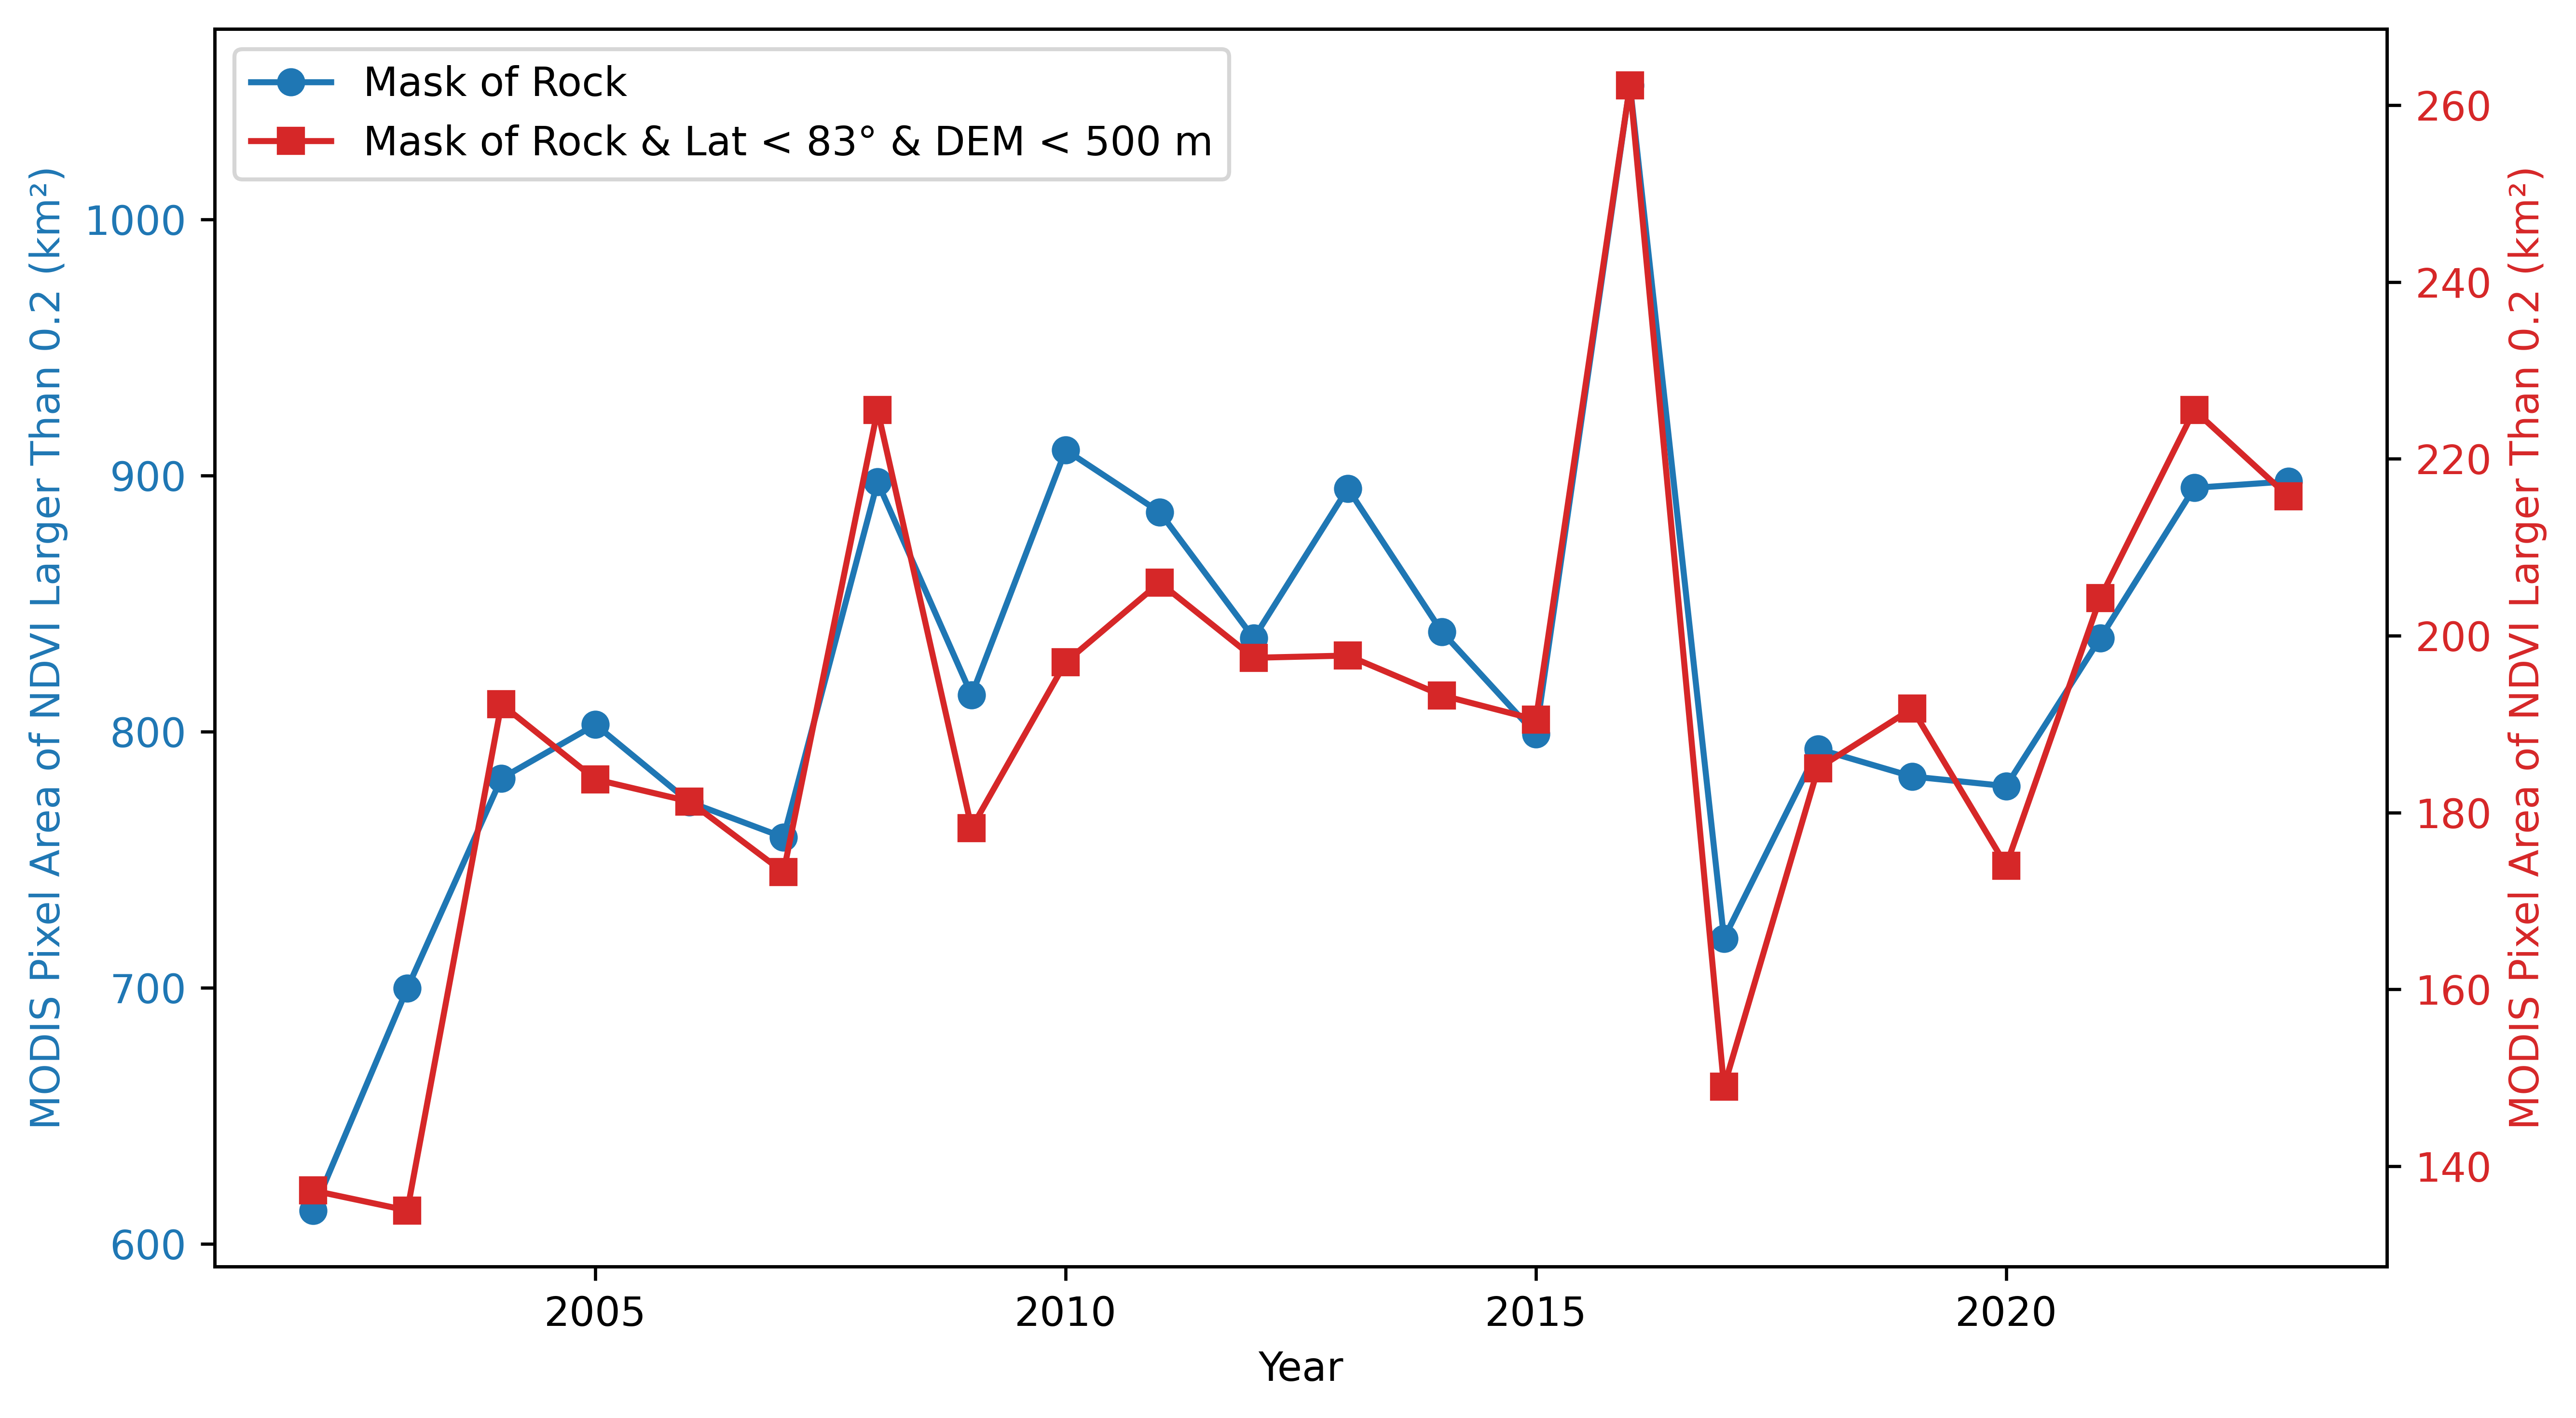

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV
df = pd.read_csv(r"G:\Hangkai\Anttarctic Vegetation Dynamic\Greenness_Area_With_Restrictions.csv")

fig, ax1 = plt.subplots(figsize=(9, 5), dpi=600)

# ---- Left axis (Rock region) ----
color1 = "tab:blue"
line1, = ax1.plot(
    df["year"],
    df["area_rock_km2"],
    marker="o",
    color=color1,
    label="Mask of Rock"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("MODIS Pixel Area of NDVI Larger Than 0.2 (km²)", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

# ---- Right axis (Restricted region) ----
ax2 = ax1.twinx()
color2 = "tab:red"
line2, = ax2.plot(
    df["year"],
    df["area_rock_polewardS2_demlt500_km2"],
    marker="s",
    color=color2,
    label="Mask of Rock & Lat < 83° & DEM < 500 m"
)

ax2.set_ylabel("MODIS Pixel Area of NDVI Larger Than 0.2 (km²)", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

# ---- Combined legend ----
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

# ---- Title ----
#plt.title("MODIS NDVI > 0.2 in Rock Regions (2002–2023)")

fig.tight_layout()
plt.savefig(r"C:\Users\hyou34\OneDrive - UW-Madison\manuscripts\paper\Greening Antarctica\nature_version\Supplementary_Information\High_Resolution_Figures\SM_Greenness_Area_With_Restrictions.png", dpi=600, bbox_inches="tight")
plt.show()